# Sepsis Prediction - Model Explainability (SHAP)

In this notebook, we explain why the trained XGBoost model predicts sepsis using SHAP (SHapley Additive exPlanations).

In [1]:
import pandas as pd
import numpy as np
import joblib
import shap
import matplotlib.pyplot as plt

In [2]:
model = joblib.load("../models/final_sepsis_model.pkl")

print("✅ Final model loaded successfully!")

✅ Final model loaded successfully!


In [3]:
test_df = pd.read_csv("../data/processed/test_processed.csv")

print("Test Shape:", test_df.shape)

test_df.head()

Test Shape: (310997, 55)


,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,Age,SepsisLabel,ICULOS,...,Resp_RollingMax_3,HR_RollingMin_3,O2Sat_RollingMin_3,Temp_RollingMin_3,SBP_RollingMin_3,MAP_RollingMin_3,DBP_RollingMin_3,Resp_RollingMin_3,PulsePressure,ShockIndex
0,83.5,98.0,37.00,121.0,80.0,62.0,18.0,75.91,0,1,...,18.0,83.5,98.0,37.00,121.0,80.0,62.0,18.0,59.0,0.690083
1,61.0,99.0,36.44,124.0,65.0,43.0,17.5,75.91,0,2,...,18.0,61.0,98.0,36.44,121.0,65.0,43.0,17.5,81.0,0.491935
2,64.0,98.0,37.00,125.0,64.0,41.0,27.0,75.91,0,3,...,27.0,61.0,98.0,36.44,121.0,64.0,41.0,17.5,84.0,0.512000
3,56.0,100.0,37.00,123.0,65.0,41.0,9.0,75.91,0,4,...,27.0,56.0,98.0,36.44,123.0,64.0,41.0,9.0,82.0,0.455285
4,66.0,99.0,37.00,120.0,67.0,43.0,23.0,75.91,0,5,...,27.0,56.0,98.0,37.00,120.0,64.0,41.0,9.0,77.0,0.550000


In [4]:
X_test = test_df.drop(columns=["SepsisLabel", "Patient_ID"])

y_test = test_df["SepsisLabel"]

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_test: (310997, 53)
y_test: (310997,)


In [5]:
# ============================================================
# Create SHAP Explainer
# ============================================================

explainer = shap.TreeExplainer(model)

print("SHAP Explainer Created!")

SHAP Explainer Created!


In [6]:
# ============================================================
# Calculate SHAP Values
# ============================================================

shap_values = explainer.shap_values(X_test)

print("SHAP Values Calculated!")

SHAP Values Calculated!


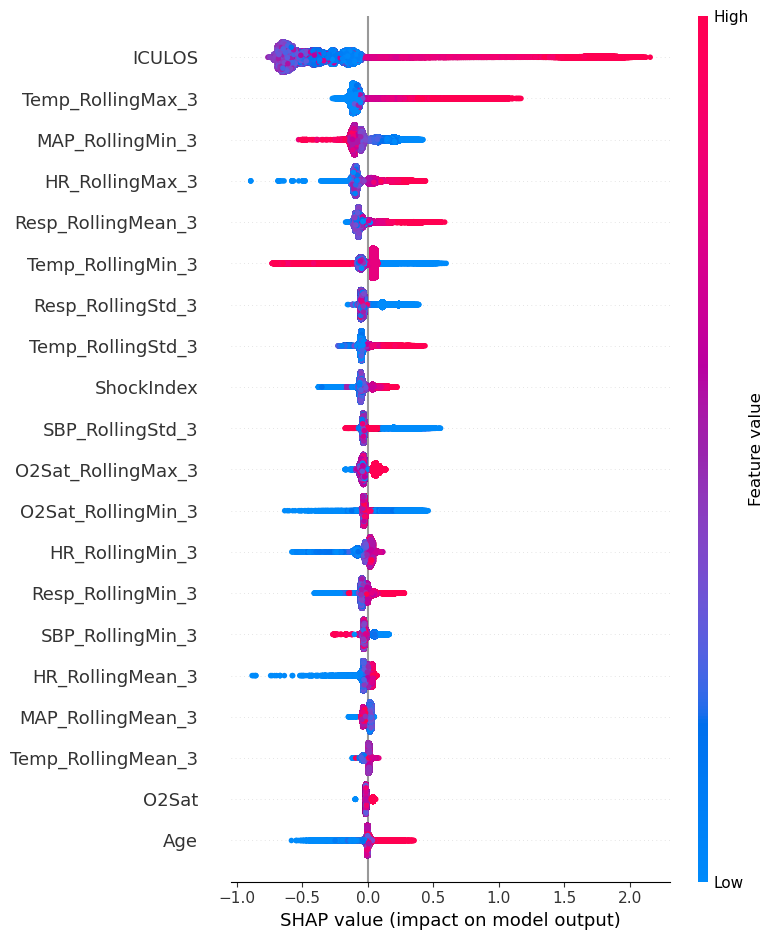

In [7]:
# ============================================================
# SHAP Summary Plot
# ============================================================

shap.summary_plot(shap_values, X_test)

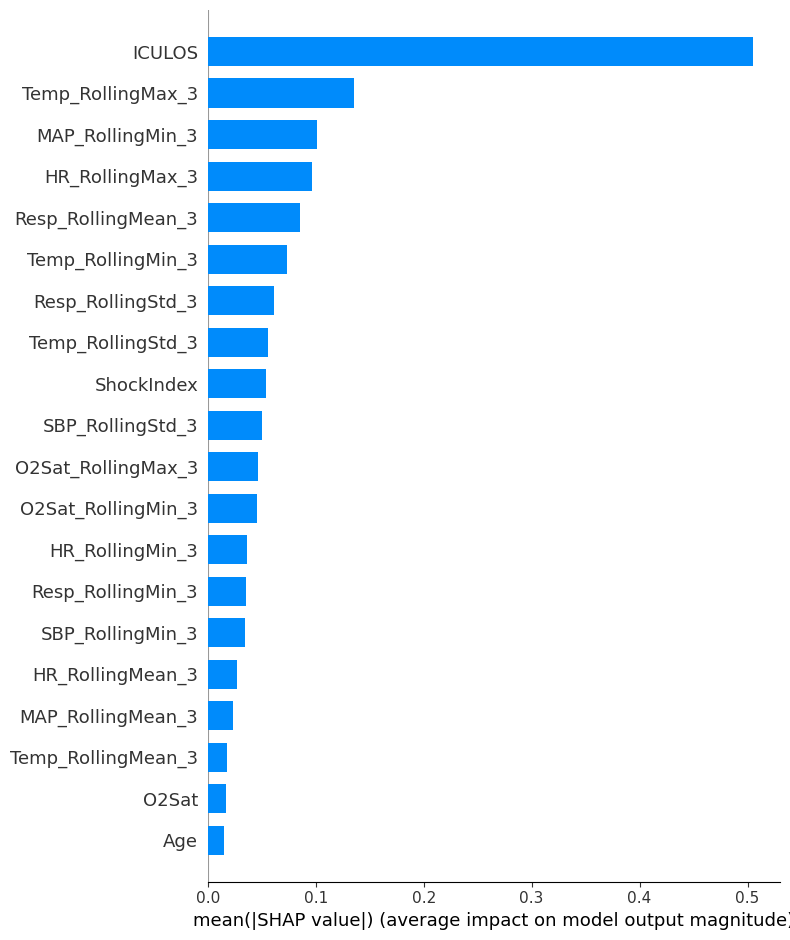

In [8]:
# ============================================================
# SHAP Feature Importance
# ============================================================

shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)

In [9]:
# -----------------------------
# SHAP Summary Plot
# -----------------------------
plt.figure(figsize=(10, 6))

shap.summary_plot(
    shap_values,
    X_test,
    show=False
)

plt.tight_layout()

plt.savefig(
    "../screenshots/shap_summary.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

print("SHAP Summary Plot Saved!")

# -----------------------------
# SHAP Bar Plot
# -----------------------------
plt.figure(figsize=(10, 6))

shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar",
    show=False
)

plt.tight_layout()

plt.savefig(
    "../screenshots/shap_bar.png",
    dpi=300,
    bbox_inches="tight"
)

plt.close()

print("SHAP Bar Plot Saved!")

SHAP Summary Plot Saved!
SHAP Bar Plot Saved!
